In [1]:
# !pip install kagglehub

In [6]:
import cv2
import json
import numpy as np
import kagglehub as kgh
import tensorflow as tf
import matplotlib.pyplot as plt
from glob import glob as gg
from zipfile import ZipFile

In [7]:
# from google.colab import drive
# drive.mount('/content/drive')

In [66]:
def segmentation_preprocessing(image_path, target_size = (1024, 256)):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, target_size)
    _, binary_image = cv2.threshold(image, 120, 255, cv2.THRESH_BINARY_INV)
    return image, binary_image

In [67]:
def segment_image(binary_image, min_contour_area = 100):

	contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

	boxes = []

	for countour in contours:
		area = cv2.contourArea(countour)
		if area < min_contour_area:
			continue
		x, y, w, h = cv2.boundingRect(countour)
	
		ar = w / float(h)
		if 0.2 < ar < 5.0:
			boxes.append((x,y,w,h))

	boxes = sorted(boxes, key = lambda b: (b[1], b[0]))
	return boxes

In [68]:
def extract_segments(image, bounding_boxes, target_size = (64,64)):
    segments = []
    for (x, y, w, h) in bounding_boxes:
        segment = image[y:y+h, x:x+w]
        if segment.size > 0:
            segment = cv2.resize(segment, target_size)
            if len(segment.shape) == 2:
                segment = cv2.cvtColor(segment, cv2.COLOR_GRAY2RGB)
            segments.append(segment)
    return segments

In [ ]:
# def synchronous_pipeline(image_path, model):
    # 

In [12]:
def plot_actual(batch):
    import matplotlib.pyplot as plt

    num = np.random.randint(0, 58)

    fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
    for idx, img in enumerate(batch[0][num:num + 5]):
        # ax[idx].imshow(img)
        ax[idx].imshow(img.astype(int))
        ax[idx].title.set_text(batch[1][num])
        ax[idx].axis("off")
        num += 1

In [13]:
def plot_predictions(batch, label_symbol, model):
    import matplotlib.pyplot as plt

    num = np.random.randint(0, 58)

    fig, ax = plt.subplots(ncols = 5, figsize = (7, 7))
    for idx, img in enumerate(batch[0][num:num + 5]):
        ax[idx].imshow(img.astype(int))

        actual_class = label_symbol[batch[1][num]]

        img_array = np.expand_dims(img, axis = 0)
        prediction = model.predict(img_array)
        predicted_class_index = np.argmax(prediction)
        predicted_class = label_symbol[predicted_class_index]

        title = f"Actual: {actual_class}\n Predicted: {predicted_class}"
        ax[idx].set_title(title)
        ax[idx].axis("off")
        num += 1

    plt.show()

In [14]:
import os
from keras.models import load_model

# model_path = "./../models/symbol_model.keras"
model_path = "models/symbol_model_03.keras"

try:
    assert os.path.exists(model_path)
except AssertionError as ae:
    print(f"Path {model_path} not found! {ae}")

model = load_model(model_path)

In [16]:
# image_dataset = kgh.dataset_download("aidapearson/ocr-data")
image_dataset = "archive"

# Cluster
# image_dataset = "/home2/va23abb/.cache/kagglehub/datasets/aidapearson/ocr-data/versions/36"

try:
    assert os.path.exists(image_dataset)
except AssertionError as ae:
    print(f"Path {image_dataset} not found! {ae}")

In [17]:
# images = gg(f"{image_dataset}/batch_*")
images = gg(f"{image_dataset}/batch_*/background_images/*")
json_files = gg(f"{image_dataset}/batch_*/JSON/*")
# /backgroung_images/*

In [ ]:
dataset = tf.keras.utils.image_dataset_from_directory(
    "symbol_images", batch_size = 64, image_size = (64, 64)
)

In [ ]:
batch = dataset.as_numpy_iterator().next()

In [50]:
symbols_dict = dict(zip((range(0, len(dataset.class_names))), dataset.class_names))

with open("symbols_dict.json", "w") as file:
    json.dump(symbols_dict, file)

[symbols_dict[n] for n in range(10)]

['+', '-', '0', '1', '2', '3', '4', '5', '6', '7']

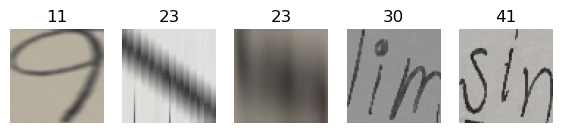

In [ ]:
plot_actual(batch)

I0000 00:00:1745922313.303201 3090233 service.cc:146] XLA service 0x7f6114008dd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745922313.303291 3090233 service.cc:154]   StreamExecutor device (0): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1745922313.303307 3090233 service.cc:154]   StreamExecutor device (1): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1745922313.303320 3090233 service.cc:154]   StreamExecutor device (2): NVIDIA A100 80GB PCIe, Compute Capability 8.0
I0000 00:00:1745922313.303325 3090233 service.cc:154]   StreamExecutor device (3): NVIDIA A100 80GB PCIe, Compute Capability 8.0
2025-04-29 11:25:13.317583: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-29 11:25:13.370546: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90101


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 873ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


I0000 00:00:1745922313.993411 3090233 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


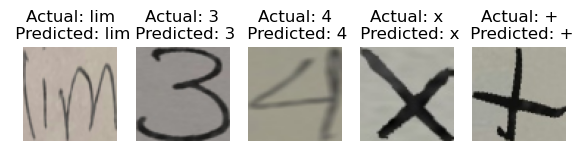

In [ ]:
plot_predictions(batch, symbols_dict, model)

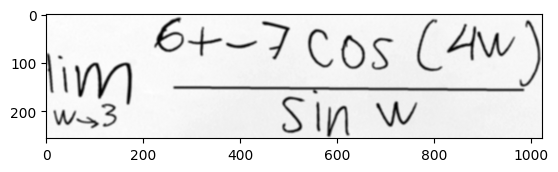

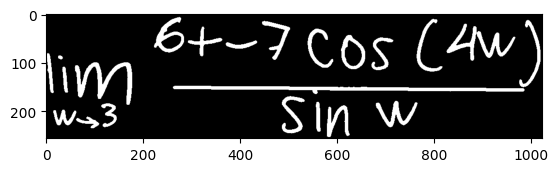

In [60]:
img, bin_img = segmentation_preprocessing(images[2])

plt.imshow(img, cmap = "grey")
plt.show()
plt.imshow(bin_img, cmap = "grey")
plt.show()


In [58]:
img, bin_img = segmentation_preprocessing(images[2])
bb = segment_image(bin_img)
bb

[(223, 8, 62, 73),
 (765, 12, 54, 108),
 (977, 14, 44, 138),
 (446, 16, 58, 80),
 (827, 22, 142, 76),
 (293, 28, 71, 61),
 (540, 32, 53, 80),
 (609, 45, 50, 70),
 (672, 50, 45, 67),
 (371, 56, 65, 17),
 (59, 101, 119, 87),
 (33, 110, 13, 53),
 (487, 170, 47, 77),
 (681, 180, 86, 54),
 (114, 185, 32, 49),
 (580, 189, 47, 65),
 (15, 198, 48, 32),
 (62, 212, 48, 24)]

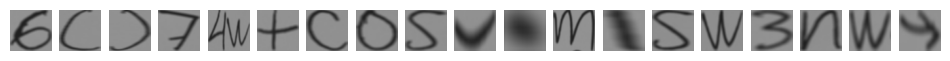

In [57]:
img, bin_img = segmentation_preprocessing(images[2])
boxes = segment_image(bin_img, min_contour_area = 10)
segments = extract_segments(img, boxes)

plt.figure(figsize = (12,4))
for i, seg in enumerate(segments):
    plt.subplot(1, len(segments), i+1)
    plt.imshow(seg, cmap = "gray")
    plt.axis("off")
plt.show()

In [65]:
output = []

for image in segments:
    
	image = image.astype("float32") / 255.0

	image = np.expand_dims(image, axis = 0)

	pred = model.predict(image)

	class_id = np.argmax(pred, axis = 1)[0]

	output_char = symbols_dict[class_id]

	output.append(output_char)

sequence = " ".join(output)

print("\n", sequence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

 6 left( right) 7 w + 0 0 s - 1 infty 1 s w 3 n w to


In [55]:
print(output)

['6', 'left(', 'right)', '7', 'w', '+', '0', '0', 's', '-', '1', 'infty', '1', 's', 'w', '3', 'n', 'w', 'to']
